In [ ]:
!pip install gymnasium

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.distributions as distributions


env = gym.make('Blackjack-v1', natural=False, sab=False)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ActorCriticGRU(nn.Module):
    def __init__(
        self,
        observation_space_size,
        action_space_size,
        hidden_size=64,
        num_layers=1
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=observation_space_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.actor_head = nn.Linear(hidden_size, action_space_size)
        self.critic_head = nn.Linear(hidden_size, 1)

    def forward(self, state):
        # state: (batch_size, obs_dim)
        state = state.unsqueeze(1)  # (batch_size, 1, obs_dim)

        gru_output, _ = self.gru(state)
        gru_output = gru_output.squeeze(1)  # (batch_size, hidden)

        action_probs = F.softmax(self.actor_head(gru_output), dim=-1)
        state_value = self.critic_head(gru_output)

        return action_probs, state_value


In [ ]:
def calculate_returns(rewards, gamma):
    returns = []
    R = 0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    return torch.tensor(returns, dtype=torch.float32)


In [ ]:
def train_actor_critic(
    env,
    observation_space_size,
    action_space_size,
    lr=1e-3,
    episodes=25_000,
    gamma=0.99,
    hidden=64,
    layers=1
):
    model = ActorCriticGRU(
        observation_space_size,
        action_space_size,
        hidden_size=hidden,
        num_layers=layers
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)

    episode_rewards = []
    actor_losses = []
    critic_losses = []

    for episode in range(episodes):
        observation, _ = env.reset()

        log_probs = []
        values = []
        rewards = []

        done = False
        truncated = False
        episode_reward = 0

        while not done and not truncated:
            obs_tensor = torch.tensor(
                observation, dtype=torch.float32
            ).unsqueeze(0)

            action_probs, critic_value = model(obs_tensor)

            dist = distributions.Categorical(probs=action_probs.squeeze(0))
            action = dist.sample()
            log_prob = dist.log_prob(action)

            next_obs, reward, done, truncated, _ = env.step(action.item())

            log_probs.append(log_prob)
            values.append(critic_value.squeeze())
            rewards.append(reward)

            observation = next_obs
            episode_reward += reward

        # Bootstrap terminal value
        values.append(torch.tensor(0.0))

        returns = calculate_returns(rewards, gamma)
        values_tensor = torch.stack(values)

        advantages = returns - values_tensor[:-1]

        actor_loss = -(torch.stack(log_probs) * advantages.detach()).mean()
        critic_loss = F.mse_loss(values_tensor[:-1], returns.detach())

        total_loss = actor_loss + critic_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        episode_rewards.append(episode_reward)
        actor_losses.append(actor_loss.item())
        critic_losses.append(critic_loss.item())

        if episode % 100 == 0:
            print(
                f"Episode {episode} | "
                f"Reward: {episode_reward:.2f} | "
                f"Actor Loss: {actor_loss.item():.4f} | "
                f"Critic Loss: {critic_loss.item():.4f}"
            )

    return model, episode_rewards, actor_losses, critic_losses


In [ ]:
model, rewards, actor_losses, critic_losses = train_actor_critic(
    env=env,
    observation_space_size=3,
    action_space_size=env.action_space.n,
    lr=0.0005,
    episodes=50000,
    gamma=0.99,
    hidden=128,
    layers=2
)


Episode 0 | Reward: -1.00 | Actor Loss: -0.7162 | Critic Loss: 1.1482
Episode 100 | Reward: 1.00 | Actor Loss: 0.0928 | Critic Loss: 1.3391
Episode 200 | Reward: 0.00 | Actor Loss: -0.0028 | Critic Loss: 0.0018
Episode 300 | Reward: -1.00 | Actor Loss: -0.0486 | Critic Loss: 0.3927
Episode 400 | Reward: -1.00 | Actor Loss: -0.0226 | Critic Loss: 1.1709
Episode 500 | Reward: -1.00 | Actor Loss: -0.0312 | Critic Loss: 0.9582
Episode 600 | Reward: -1.00 | Actor Loss: -0.0313 | Critic Loss: 0.7979
Episode 700 | Reward: 1.00 | Actor Loss: 0.0124 | Critic Loss: 0.6467
Episode 800 | Reward: -1.00 | Actor Loss: -0.0274 | Critic Loss: 0.5535
Episode 900 | Reward: 1.00 | Actor Loss: 0.0729 | Critic Loss: 1.3032
Episode 1000 | Reward: 1.00 | Actor Loss: 0.0283 | Critic Loss: 0.5796
Episode 1100 | Reward: -1.00 | Actor Loss: -0.2215 | Critic Loss: 0.1586
Episode 1200 | Reward: 1.00 | Actor Loss: 0.1427 | Critic Loss: 1.4721
Episode 1300 | Reward: -1.00 | Actor Loss: -0.0239 | Critic Loss: 0.2385
E

In [ ]:
import numpy as np
import torch

def evaluate_agent(
    model,
    env,
    num_test_episodes=10_000,
    device="cpu"
):
    model.eval()
    model.to(device)

    total_rewards = []
    wins = 0

    with torch.no_grad():
        for episode in range(num_test_episodes):
            observation, _ = env.reset()
            episode_reward = 0
            done = False
            truncated = False

            while not (done or truncated):
                # Convert observation to tensor: (1, obs_dim)
                obs_tensor = torch.tensor(
                    observation, dtype=torch.float32
                ).unsqueeze(0).to(device)

                # Forward pass
                action_probs, _ = model(obs_tensor)

                # Greedy action selection
                action = torch.argmax(action_probs, dim=1).item()

                observation, reward, done, truncated, _ = env.step(action)
                episode_reward += reward

            total_rewards.append(episode_reward)
            if episode_reward > 0:
                wins += 1

    avg_reward = np.mean(total_rewards)
    win_rate = wins / num_test_episodes

    print(f"\nEvaluation over {num_test_episodes} episodes:")
    print(f"Average Reward: {avg_reward:.4f}")
    print(f"Win Rate: {win_rate * 100:.2f}%")

    return avg_reward, win_rate


In [ ]:
configs = [
    {
        "name": "Shallow (1 Layer) gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 128, "layers": 1
    },
    {
        "name": "Deep (2 Layers) gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 128, "layers": 2
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.95,
        "hidden": 128, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 256 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 256, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 512 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 512, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 512 hidden layers and greater learning rate",
        "lr": 0.001, "episodes": 10000, "gamma": 0.99,
        "hidden": 512, "layers": 1
    },

]

In [ ]:
def run_experiments(
    env,
    configs,
    observation_space_size,
    action_space_size,
    eval_episodes=10_000,
    device="cpu"
):
    results = []

    for cfg in configs:
        print("\n" + "=" * 80)
        print(f"Running experiment: {cfg['name']}")
        print("=" * 80)

        # Train
        model, train_rewards, actor_losses, critic_losses = train_actor_critic(
            env=env,
            observation_space_size=observation_space_size,
            action_space_size=action_space_size,
            lr=cfg["lr"],
            episodes=cfg["episodes"],
            gamma=cfg["gamma"],
            hidden=cfg["hidden"],
            layers=cfg["layers"],
        )

        # Evaluate
        avg_reward, win_rate = evaluate_agent(
            model=model,
            env=env,
            num_test_episodes=eval_episodes,
            device=device,
        )

        results.append({
            "name": cfg["name"],
            "lr": cfg["lr"],
            "episodes": cfg["episodes"],
            "gamma": cfg["gamma"],
            "hidden": cfg["hidden"],
            "layers": cfg["layers"],
            "avg_reward": avg_reward,
            "win_rate": win_rate,
        })

    return results


In [ ]:
results = run_experiments(
    env=env,
    configs=configs,
    observation_space_size=3,
    action_space_size=env.action_space.n,
    eval_episodes=10000,
    device="cpu",
)



Running experiment: Shallow (1 Layer) gamma 0.99 and 128 hidden layers
Episode 0 | Reward: -1.00 | Actor Loss: -0.7252 | Critic Loss: 0.9000
Episode 100 | Reward: -1.00 | Actor Loss: -0.1876 | Critic Loss: 0.5559
Episode 200 | Reward: -1.00 | Actor Loss: -0.1090 | Critic Loss: 0.6495
Episode 300 | Reward: -1.00 | Actor Loss: -0.0632 | Critic Loss: 0.6059
Episode 400 | Reward: 1.00 | Actor Loss: 1.6383 | Critic Loss: 1.7418
Episode 500 | Reward: 1.00 | Actor Loss: 0.0264 | Critic Loss: 0.7929
Episode 600 | Reward: 1.00 | Actor Loss: 0.0520 | Critic Loss: 1.4026
Episode 700 | Reward: -1.00 | Actor Loss: -0.0184 | Critic Loss: 0.2823
Episode 800 | Reward: 1.00 | Actor Loss: 0.0066 | Critic Loss: 0.5022
Episode 900 | Reward: 1.00 | Actor Loss: 0.0180 | Critic Loss: 1.1285
Episode 1000 | Reward: -1.00 | Actor Loss: -0.2819 | Critic Loss: 0.1957
Episode 1100 | Reward: 1.00 | Actor Loss: 0.0179 | Critic Loss: 1.6993
Episode 1200 | Reward: 0.00 | Actor Loss: -0.0003 | Critic Loss: 0.0031
Epis

In [ ]:
import matplotlib.pyplot as plt

def plot_experiment_results(results, sort_by="win_rate"):
    results = sorted(results, key=lambda x: x[sort_by], reverse=True)

    names = [r["name"] for r in results]
    avg_rewards = [r["avg_reward"] for r in results]
    win_rates = [r["win_rate"] for r in results]

    # --- Average Reward ---
    plt.figure(figsize=(10, 6))
    plt.barh(names, avg_rewards)
    plt.xlabel("Average Reward")
    plt.title("Average Reward per Configuration")
    for i, v in enumerate(avg_rewards):
        plt.text(v, i, f"{v:.3f}", va="center")
    plt.tight_layout()
    plt.show()

    # --- Win Rate ---
    plt.figure(figsize=(10, 6))
    plt.barh(names, win_rates)
    plt.xlabel("Win Rate")
    plt.title("Win Rate per Configuration")
    for i, v in enumerate(win_rates):
        plt.text(v, i, f"{v*100:.2f}%", va="center")
    plt.tight_layout()
    plt.show()


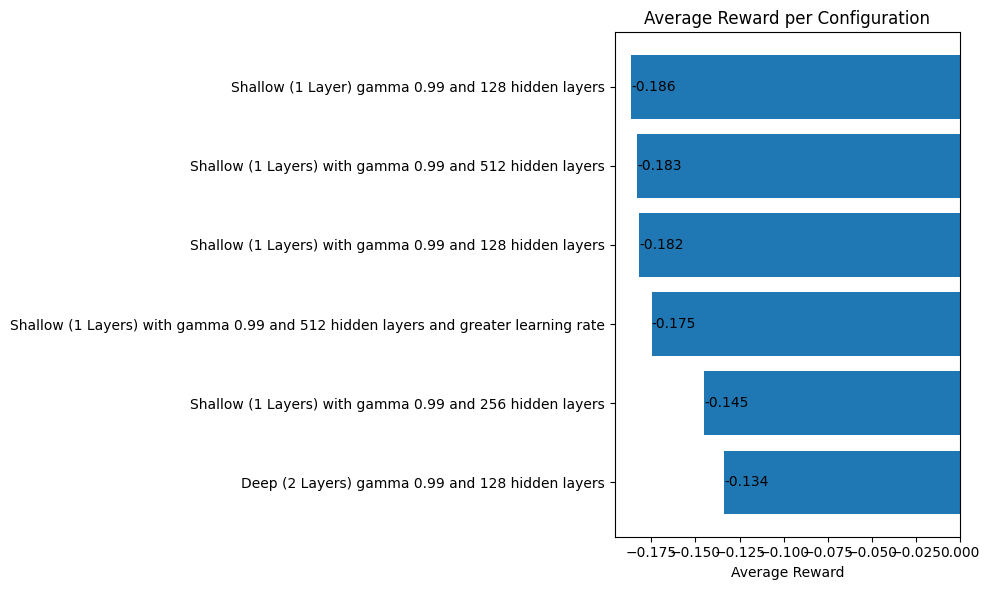

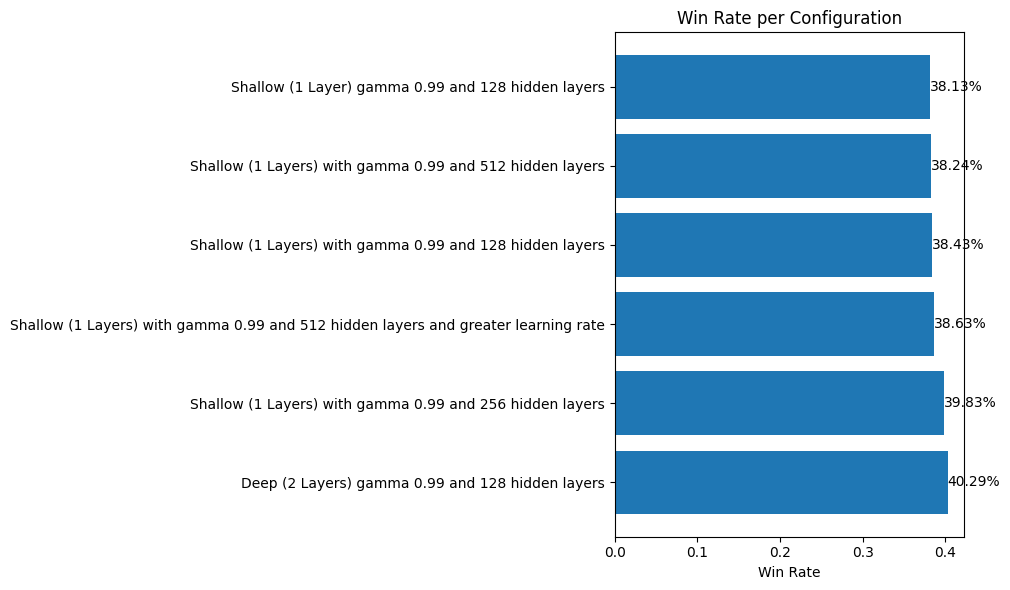

In [ ]:
plot_experiment_results(results)


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.4 MB/s eta 0:00:00


In [ ]:
import optuna

def objective(trial):
    # --- Hyperparameters to tune ---
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    hidden = trial.suggest_categorical("hidden", [128, 256, 512])
    layers = trial.suggest_int("layers", 1, 3)
    gamma = trial.suggest_float("gamma", 0.9, 0.999)

    # --- Training / Evaluation budgets ---
    train_episodes = 20_000   # smaller for tuning
    eval_episodes = 1_000

    # --- Train model ---
    model, _, _, _ = train_actor_critic(
        env=env,
        observation_space_size=observation_space_size,
        action_space_size=action_space_size,
        lr=lr,
        episodes=train_episodes,
        gamma=gamma,
        hidden=hidden,
        layers=layers,
    )

    # --- Evaluate ---
    avg_reward, win_rate = evaluate_agent(
        model=model,
        env=env,
        num_test_episodes=eval_episodes,
        device="cpu"
    )

    # --- Objective to maximize ---
    # Option 1 (recommended): maximize win rate
    return win_rate

    # Option 2: maximize average


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best trial:")
print(study.best_trial)


[I 2026-01-21 18:41:00,128] A new study created in memory with name: no-name-6b9ad9fe-dcb3-4cc0-8e61-6dc327f03f92


Episode 0 | Reward: 1.00 | Actor Loss: 0.6132 | Critic Loss: 0.7902
Episode 100 | Reward: -1.00 | Actor Loss: -0.2185 | Critic Loss: 0.9733
Episode 200 | Reward: -1.00 | Actor Loss: -1.5520 | Critic Loss: 0.4656
Episode 300 | Reward: -1.00 | Actor Loss: -0.0191 | Critic Loss: 0.5965
Episode 400 | Reward: -1.00 | Actor Loss: -0.0198 | Critic Loss: 0.3200
Episode 500 | Reward: -1.00 | Actor Loss: -0.0097 | Critic Loss: 0.5676
Episode 600 | Reward: -1.00 | Actor Loss: -0.0181 | Critic Loss: 1.1249
Episode 700 | Reward: 0.00 | Actor Loss: -0.0004 | Critic Loss: 0.0062
Episode 800 | Reward: -1.00 | Actor Loss: -0.0069 | Critic Loss: 1.9643
Episode 900 | Reward: -1.00 | Actor Loss: -0.0536 | Critic Loss: 0.6048
Episode 1000 | Reward: -1.00 | Actor Loss: -0.0731 | Critic Loss: 0.7547
Episode 1100 | Reward: -1.00 | Actor Loss: -0.1863 | Critic Loss: 0.4058
Episode 1200 | Reward: 1.00 | Actor Loss: 0.0124 | Critic Loss: 0.5375
Episode 1300 | Reward: 1.00 | Actor Loss: 0.0146 | Critic Loss: 1.29

[I 2026-01-21 18:46:55,886] Trial 0 finished with value: 0.412 and parameters: {'lr': 0.0004735091567082597, 'hidden': 512, 'layers': 1, 'gamma': 0.9784194374560125}. Best is trial 0 with value: 0.412.



Evaluation over 1000 episodes:
Average Reward: -0.1150
Win Rate: 41.20%
Episode 0 | Reward: -1.00 | Actor Loss: -0.6146 | Critic Loss: 0.7595
Episode 100 | Reward: -1.00 | Actor Loss: -0.3740 | Critic Loss: 0.5091
Episode 200 | Reward: -1.00 | Actor Loss: -0.4138 | Critic Loss: 0.4054
Episode 300 | Reward: -1.00 | Actor Loss: -0.1819 | Critic Loss: 0.4685
Episode 400 | Reward: 0.00 | Actor Loss: 0.4607 | Critic Loss: 0.1427
Episode 500 | Reward: 1.00 | Actor Loss: 0.1240 | Critic Loss: 1.4554
Episode 600 | Reward: 1.00 | Actor Loss: 0.1051 | Critic Loss: 1.1088
Episode 700 | Reward: -1.00 | Actor Loss: -0.0503 | Critic Loss: 0.4339
Episode 800 | Reward: 1.00 | Actor Loss: 0.0917 | Critic Loss: 1.5759
Episode 900 | Reward: -1.00 | Actor Loss: -0.0629 | Critic Loss: 1.2467
Episode 1000 | Reward: -1.00 | Actor Loss: -0.0937 | Critic Loss: 1.0508
Episode 1100 | Reward: -1.00 | Actor Loss: -0.0509 | Critic Loss: 1.2049
Episode 1200 | Reward: -1.00 | Actor Loss: -0.0260 | Critic Loss: 0.077

[I 2026-01-21 18:48:48,186] Trial 1 finished with value: 0.379 and parameters: {'lr': 0.00010559549320323473, 'hidden': 128, 'layers': 2, 'gamma': 0.9484477294523268}. Best is trial 0 with value: 0.412.


...


Evaluation over 1000 episodes:
Average Reward: -0.0960
Win Rate: 41.90%
Episode 0 | Reward: -1.00 | Actor Loss: -0.6600 | Critic Loss: 0.8639
Episode 100 | Reward: -1.00 | Actor Loss: -1.2337 | Critic Loss: 0.4813
Episode 200 | Reward: 1.00 | Actor Loss: 0.1325 | Critic Loss: 1.1048
Episode 300 | Reward: -1.00 | Actor Loss: -0.0755 | Critic Loss: 0.5928
Episode 400 | Reward: -1.00 | Actor Loss: -0.0766 | Critic Loss: 0.1401
Episode 500 | Reward: -1.00 | Actor Loss: -0.0379 | Critic Loss: 0.8361
Episode 600 | Reward: -1.00 | Actor Loss: -0.0363 | Critic Loss: 1.6152
Episode 700 | Reward: 1.00 | Actor Loss: 0.0025 | Critic Loss: 0.3401
Episode 800 | Reward: -1.00 | Actor Loss: -0.0090 | Critic Loss: 0.6748
Episode 900 | Reward: 1.00 | Actor Loss: 0.0141 | Critic Loss: 1.5103
Episode 1000 | Reward: 1.00 | Actor Loss: 0.0106 | Critic Loss: 1.2731
Episode 1100 | Reward: 1.00 | Actor Loss: 0.0021 | Critic Loss: 0.2646
Episode 1200 | Reward: -1.00 | Actor Loss: -0.0388 | Critic Loss: 0.0227


[I 2026-01-21 20:57:29,153] Trial 28 finished with value: 0.401 and parameters: {'lr': 0.00021543300845356904, 'hidden': 512, 'layers': 2, 'gamma': 0.9434105151961721}. Best is trial 2 with value: 0.439.



Evaluation over 1000 episodes:
Average Reward: -0.1100
Win Rate: 40.10%
Episode 0 | Reward: 1.00 | Actor Loss: 0.8553 | Critic Loss: 1.1086
Episode 100 | Reward: 1.00 | Actor Loss: 0.2969 | Critic Loss: 2.2087
Episode 200 | Reward: 1.00 | Actor Loss: 0.1391 | Critic Loss: 1.5756
Episode 300 | Reward: -1.00 | Actor Loss: -0.0713 | Critic Loss: 0.5950
Episode 400 | Reward: -1.00 | Actor Loss: -0.1143 | Critic Loss: 0.6594
Episode 500 | Reward: -1.00 | Actor Loss: -0.0476 | Critic Loss: 0.6788
Episode 600 | Reward: 1.00 | Actor Loss: 0.0093 | Critic Loss: 0.3224
Episode 700 | Reward: -1.00 | Actor Loss: -0.0889 | Critic Loss: 0.2970
Episode 800 | Reward: -1.00 | Actor Loss: -0.0643 | Critic Loss: 0.6649
Episode 900 | Reward: 1.00 | Actor Loss: 0.0200 | Critic Loss: 0.7958
Episode 1000 | Reward: -1.00 | Actor Loss: -1.0410 | Critic Loss: 0.5558
Episode 1100 | Reward: 0.00 | Actor Loss: -0.0010 | Critic Loss: 0.0067
Episode 1200 | Reward: 1.00 | Actor Loss: 0.0010 | Critic Loss: 0.6990
Epi

[I 2026-01-21 20:59:32,785] Trial 29 finished with value: 0.395 and parameters: {'lr': 0.0005424057299065294, 'hidden': 256, 'layers': 1, 'gamma': 0.9668784889444462}. Best is trial 2 with value: 0.439.



Evaluation over 1000 episodes:
Average Reward: -0.1360
Win Rate: 39.50%
Best trial:
FrozenTrial(number=2, state=<TrialState.COMPLETE: 1>, values=[0.439], datetime_start=datetime.datetime(2026, 1, 21, 18, 48, 48, 187687), datetime_complete=datetime.datetime(2026, 1, 21, 18, 51, 30, 976886), params={'lr': 0.00047766658776892133, 'hidden': 128, 'layers': 3, 'gamma': 0.9156126585377491}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'hidden': CategoricalDistribution(choices=(128, 256, 512)), 'layers': IntDistribution(high=3, log=False, low=1, step=1), 'gamma': FloatDistribution(high=0.999, log=False, low=0.9, step=None)}, trial_id=2, value=None)


In [ ]:
print("\nBest hyperparameters found:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")


Best hyperparameters found:
lr: 0.00047766658776892133
hidden: 128
layers: 3
gamma: 0.9156126585377491


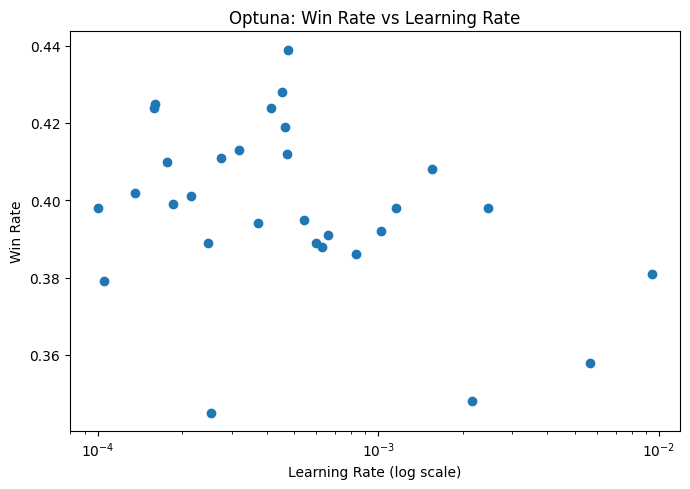

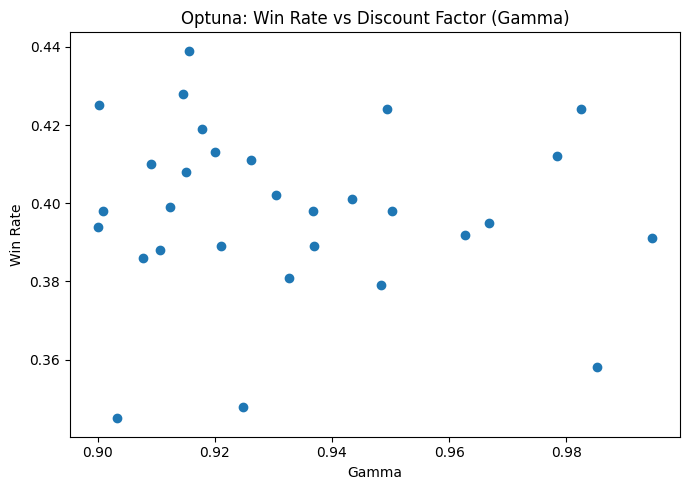

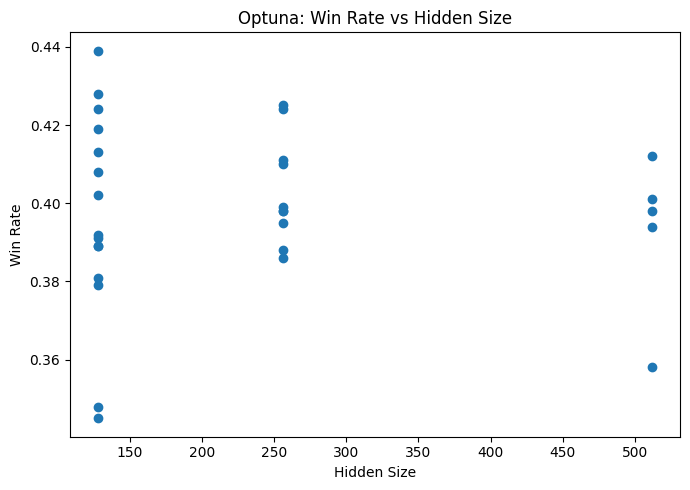

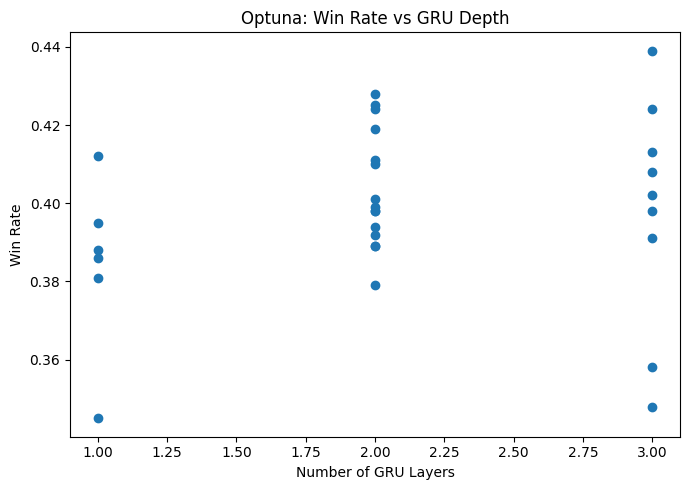

In [ ]:
import matplotlib.pyplot as plt

# Extract completed trials
trials = [t for t in study.trials if t.value is not None]

# Objective values
win_rates = [t.value for t in trials]

# Hyperparameters
lrs = [t.params["lr"] for t in trials]
gammas = [t.params["gamma"] for t in trials]
hidden_sizes = [t.params["hidden"] for t in trials]
num_layers = [t.params["layers"] for t in trials]

# --- Win Rate vs Learning Rate ---
plt.figure(figsize=(7, 5))
plt.scatter(lrs, win_rates)
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Learning Rate")
plt.tight_layout()
plt.show()

# --- Win Rate vs Gamma ---
plt.figure(figsize=(7, 5))
plt.scatter(gammas, win_rates)
plt.xlabel("Gamma")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Discount Factor (Gamma)")
plt.tight_layout()
plt.show()

# --- Win Rate vs Hidden Size ---
plt.figure(figsize=(7, 5))
plt.scatter(hidden_sizes, win_rates)
plt.xlabel("Hidden Size")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Hidden Size")
plt.tight_layout()
plt.show()

# --- Win Rate vs GRU Layers ---
plt.figure(figsize=(7, 5))
plt.scatter(num_layers, win_rates)
plt.xlabel("Number of GRU Layers")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs GRU Depth")
plt.tight_layout()
plt.show()


In [ ]:
best = study.best_trial

print("\nBest Trial Summary")
print("------------------")
print(f"Win Rate: {best.value:.4f}")
for k, v in best.params.items():
    print(f"{k}: {v}")



Best Trial Summary
------------------
Win Rate: 0.4390
lr: 0.00047766658776892133
hidden: 128
layers: 3
gamma: 0.9156126585377491
